In [1]:
# generates a graph rag from  a set of manually written triplets
# a function to lookup the context of the entity from the query

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool

d:\Code\ak\langchain-academy\lc-academy-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:

# 1. BUILD THE KNOWLEDGE GRAPH (The "Index")
# In a real scenario, you'd use an LLM to extract these triples.
# Here, we manually define the 'triples' found in your text.

# kg = nx.MultiDiGraph()
kg = nx.MultiDiGraph()

triples = [
    ("Child 1", "picks", "Prime Number"),
    ("Father", "must_be", "Extra Formal"),
    ("Prime Number", "triggers", "Father's Formality"),
    ("Odd Numbers", "are_considered", "High Volatility"),
    ("Even Numbers", "are_considered", "Stable Assets"),
    ("Stable Assets", "means", "Even Numbers")
]

for subject, relation, obj in triples:
    kg.add_edge(subject, obj, relation=relation)


In [13]:
# 2. DEFINE THE GRAPH TOOL
@tool
def graph_lookup(entity_query: str):
    """Consult the Knowledge Graph to see relationships for a specific entity.
    Look up a SINGLE entitty in the knowledge graph to find its relations.
    If you need to lookup multiple entities, make separate tool calls for each entity"""    # We find the node and its immediate connections (neighbors)
    
    results = []
    for neighbor in kg.neighbors(entity_query):
        edge_data = kg.get_edge_data(entity_query, neighbor)
        relation = edge_data[0]['relation']
        results.append(f"{entity_query} {relation} {neighbor}")
    
    return "\n".join(results) if results else "No direct relationships found."

In [14]:
# 3. THE AGENT LOOP
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash") # Or your preferred version
llm_with_tools = llm.bind_tools([graph_lookup])

query = "What are considered 'Stable Assets' and what happens if Child 1 picks a prime number?"

# The LLM identifies 'Stable Assets' and 'Child 1' as entities to lookup
ai_msg = llm_with_tools.invoke(query)
print(f"AI Choice: {ai_msg.tool_calls}")

AI Choice: [{'name': 'graph_lookup', 'args': {'entity_query': 'Stable Assets'}, 'id': 'f9d371f5-82da-4d11-b1c0-d1bd40f05978', 'type': 'tool_call'}]


In [15]:
entities_to_lookup = [tool["args"]["entity_query"]  for tool in ai_msg.tool_calls]

In [16]:
context_each_entity = [graph_lookup.invoke(entity) for entity in entities_to_lookup]
context = "\n".join(context_each_entity)

final_response = llm.invoke(f"Context: {context}\n\nQuestion: {query}") 

print("\n--- FINAL ANSWER ---")
print(final_response.content)


--- FINAL ANSWER ---
Based on the context provided:

1.  **What are considered 'Stable Assets'?**
    'Stable Assets' are **even numbers**.

2.  **What happens if Child 1 picks a prime number?**
    *   If Child 1 picks the prime number **2**, it **is considered a Stable Asset** because 2 is an even number.
    *   If Child 1 picks any other prime number (e.g., 3, 5, 7, 11), it **is NOT considered a Stable Asset** because all other prime numbers are odd, and only even numbers are Stable Assets.


In [17]:
print(context_each_entity)

['Stable Assets means Even Numbers']


### Visualize the graph

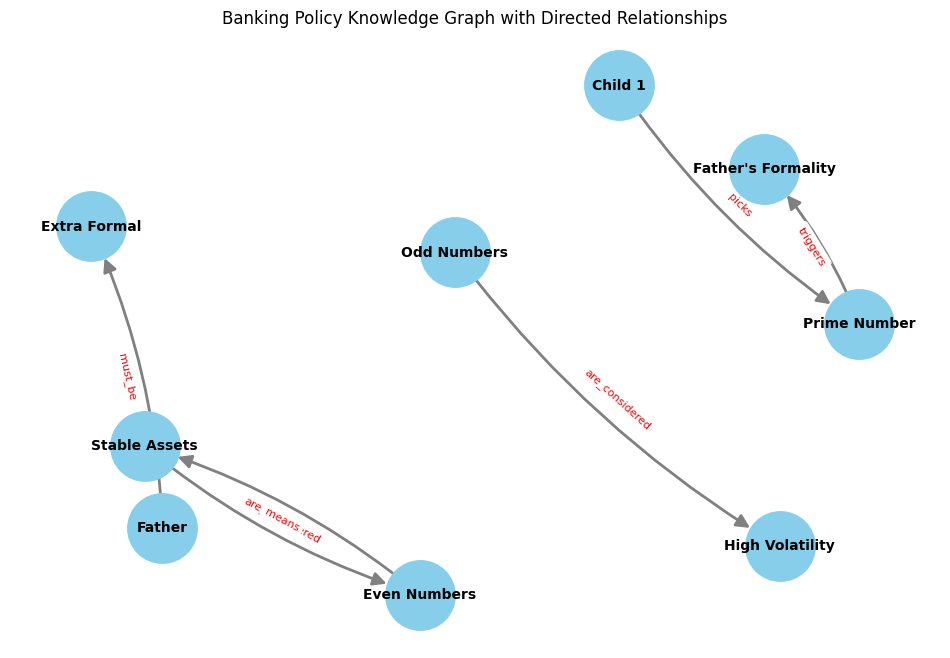

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_knowledge_graph(graph):
    plt.figure(figsize=(12, 8))
    
    # spring_layout helps spread out nodes so arrows are visible
    pos = nx.spring_layout(graph, k=1.5, seed=42) 
    
    # 1. Draw the Nodes
    nx.draw_networkx_nodes(graph, pos, node_color='skyblue', node_size=2500)
    
    # 2. Draw the Edges with Arrows
    nx.draw_networkx_edges(
        graph, 
        pos, 
        arrowstyle='-|>', 
        arrowsize=20, 
        edge_color='gray',
        width=2,
        node_size=2500, # ADD THIS: Tells the edge where to stop
        connectionstyle='arc3,rad=0.1' # Small radius helps if arrows overlap
    )
    
    # 3. Draw the Node Labels
    nx.draw_networkx_labels(graph, pos, font_size=10, font_weight='bold')
    
    # 4. Draw the Relationship Labels (The "Edges")
    edge_labels = {(u, v): d['relation'] for u, v, d in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color='red', font_size=8)
    
    plt.title("Banking Policy Knowledge Graph with Directed Relationships")
    plt.axis('off') # Hide the grid/axis
    plt.show()

# Run the visualization
visualize_knowledge_graph(kg)

# Using an LLM to automate the triplet generation

In [19]:

raw_text = """
Banking Policy 101: If Child 1 picks a prime number, the Father must be extra formal.
Banking Policy 102: Odd numbers are considered 'High Volatility' in this simulation.
Banking Policy 103: Even numbers are considered 'Stable Assets'.
"""

extraction_prompt = f"""
Extract a Knowledge Graph from the text below. 
Rules:
1. Identify Entities (Nodes) and their Relationships (Edges).
2. NORMALIZE: Convert all entities to title case (e.g., 'even numbers' -> 'Even Numbers').
3. OUTPUT: Provide a list of triples in the format: [["Subject", "Relationship", "Object"]].

Text: {raw_text}
"""

In [20]:
# structured output
from pydantic import BaseModel, Field


llm_model = llm.with_structured_output(Triads) 
response = llm_model.invoke(input=extraction_prompt)

NameError: name 'Triads' is not defined

In [ ]:
all_triplets = response.list_of_triplets
all_triplets

[['Child 1', 'Picks', 'Prime Number'],
 ['Father', 'Must Be', 'Extra Formal'],
 ['Odd Numbers', 'Are Considered', 'High Volatility'],
 ['Even Numbers', 'Are Considered', 'Stable Assets']]